In [ ]:
import os.path as path
import numpy as np
import Corrfunc
from Corrfunc.theory import wp
from Corrfunc.theory.DDrppi import DDrppi
import fitsio
import matplotlib.pyplot as plt
import import_ipynb
import statistics


plt.style.use('MNRAS')
galaxies = "/projects/hywu/cluster_sims/cluster_finding/data/emulator_data/base_c000_ph000/z0p300/model_hod000000/gals.fit"
halos = "/projects/hywu/cluster_sims/cluster_finding/data/AbacusSummit_base/base_c000/base_c000_ph000/z0p300/halos_3e+12.fit"

In [2]:
# returns x, y, z positions arrays from fits file
def create_data(fname, var = '', min_ = 0):
    data = fitsio.read(fname)
    if (var == ''): 
        x = np.array(data['px'], dtype=np.float64, order='C')
        y = np.array(data['py'], dtype=np.float64, order='C')
        z = np.array(data['pz'], dtype=np.float64, order='C')
    else: 
        x = np.array(data['px'], dtype=np.float64, order='C')[data[var] > min_]
        y = np.array(data['py'], dtype=np.float64, order='C')[data[var] > min_]
        z = np.array(data['pz'], dtype=np.float64, order='C')[data[var] > min_]
    return x, y, z

def error_data(rpavg_, wp_):
    wp_mean = []
    rpavg_mean = []
    stdev = []
    for i in range(20):
        all_wp = []
        all_rpavg = []
        for arr in range(20):
            all_wp.append(wp_[arr][i])
            all_rpavg.append(rpavg_[arr][i])
        wp_mean.append(statistics.mean(all_wp))
        rpavg_mean.append(statistics.mean(all_rpavg))
        stdev.append(statistics.stdev(all_wp))
    return rpavg_mean, wp_mean, stdev

# divides the data into subvolumes and returns the positions, section limits, and bin ids
def subvolume_calc(fname, sub_ = 4, var = '', min_ = 0):

    x, y, z = create_data(fname, var = var, min_ = min_)

    boxsize = np.max(x)
    subvol_boxsize = boxsize / sub_

    bin_id = []

    for i in range(len(x)):
        d_one = int(min(x[i] // subvol_boxsize, sub_ - 1))
        d_two = int(min(y[i] // subvol_boxsize, sub_ - 1))
        d_three = int(min(z[i] // subvol_boxsize, sub_ - 1))
        bin_id.append((d_one * sub_ * sub_) + (d_two * sub_) + d_three)

    sections = np.cumsum(np.bincount(np.array(bin_id)))
    sections = np.append(sections, 0)
    bin_id = np.argsort(np.array(bin_id))

    return x, y, z, sections, bin_id

# calculates cross-correlation wp values 
def wp_pairs_cross(X1, Y1, Z1, X2, Y2, Z2, pimax, bins, boxsize):
    wp = []
    rpavg = []
    autocorr=0
    nthreads=4
    N1 = len(X1)
    N2 = len(X2)

    # Produces rppi 
    DD_counts = DDrppi(autocorr, nthreads, pimax, bins, X1, Y1, Z1,
               X2=X2, Y2=Y2, Z2=Z2,periodic = True, boxsize = boxsize, 
               verbose=True, output_rpavg=True)
    
    # Looping through dd_counts/pimax: b/c pimax indicates max z axis comp length, only 
    # looking at range of 1 pimax/bin per iteration
    for n in range(0, int(len(DD_counts)/int(pimax))):

        # var to store calculated wp value
        wp_ = 0
        rpavg_ = 0
        total_pairs = 0

        # In order to properly access each DD_ count
        for m in range(0, int(pimax)):

            # Which DD_count point to get; If above loop were just DD_counts, index = current DD_count
            index = n*int(pimax) + m

            # DD_ = npairs
            DD_ = DD_counts[index][4]


            # N1 * N2 = total num pairs in xy plane of first dataset
            # /(boxsize**3) = total area of 3d map
            # * 2 ??? 
            # pi * (DD_counts[index][1] ** 2 - DD_counts[index][0] ** 2) 
            # Overall: Calculating npairs random
            RR_ = N1*N2/(boxsize**3.) * 2 * np.pi * (DD_counts[index][1]**2. - DD_counts[index][0]**2.)

            # added to get weighted rpavg
            rpavg_ += DD_counts[index][2] * DD_
            total_pairs += DD_

            # (rp, pi)*dpi = (DD/RR) - 1 = npairs simulation/npairs random - 1
            # In Corrunc research paper: wp(rp) = 2 * [0 to pimax]integral ((rp, pi)*dpi) ==> wp(rp) = 2 * [0 to pimax]integral
            # I think according to formula that wp_ should be multiplied by 2 after summation
            wp_ += 2.0 * ( DD_ / RR_ - 1)
            
        wp.append(wp_)
        rpavg.append(rpavg_/total_pairs)
    return wp, rpavg

# calculates subvolume wp values for galaxy and halo data
def wp_subvolumes(galaxy, halo, h_var = '', h_min = 0, sub_ = 4, pimax = 100, nbins = 20,):
    hx_arr, hy_arr, hz_arr, h_sections, h_bin_id = subvolume_calc(halo, sub_ = sub_, var = h_var, min_ = h_min)
    gx_arr, gy_arr, gz_arr, g_sections, g_bin_id = subvolume_calc(galaxy, sub_ = sub_)
    all_wp = []
    all_rpavg = []

    rmin = 0.1
    rmax = 20.0
    rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)

    for i in range(0, (sub_**3)):
        sub_vol_gx = gx_arr[g_bin_id[g_sections[i - 1]: g_sections[i]]]
        sub_vol_gy = gy_arr[g_bin_id[g_sections[i - 1]: g_sections[i]]]
        sub_vol_gz = gz_arr[g_bin_id[g_sections[i - 1]: g_sections[i]]]
        sub_vol_hx = hx_arr[h_bin_id[h_sections[i - 1]: h_sections[i]]]
        sub_vol_hy = hy_arr[h_bin_id[h_sections[i - 1]: h_sections[i]]]
        sub_vol_hz = hz_arr[h_bin_id[h_sections[i - 1]: h_sections[i]]]
        
        boxsize = max(np.max(sub_vol_gx), np.max(sub_vol_gx)) - min(np.min(sub_vol_gx), np.min(sub_vol_gx))

        wp_, rpavg_ = wp_pairs_cross(sub_vol_gx, sub_vol_gy, sub_vol_gz, sub_vol_hx, sub_vol_hy, sub_vol_hz, pimax = pimax, bins = rbins, boxsize=boxsize)
        all_wp.append(wp_)
        all_rpavg.append(rpavg_)
    
    return all_wp, all_rpavg


In [3]:
def plot_results(rpavg_, wp_, labels = '', error = [], y_max = 0, y_min = 0):
    for i in range(len(wp_)):
        plt.plot(rpavg_[i], wp_[i])
    if y_max > 0:
        plt.ylim(y_min, y_max)
    plt.legend(labels, bbox_to_anchor= (1.5, 1), loc='upper right')
    plt.title(r'$w_p$ vs $\langle r_p\rangle$')
    plt.xlabel(r'$\langle r_p\rangle$')
    plt.ylabel(r'$w_p$')
    if (len(error) > 0):
        plt.errorbar(rpavg_, wp_, yerr = error)
    plt.loglog()

def wp_vs_rpavg(rpavg_, wp_, y_max = 0, y_min = 0):
    rpavg_mean, wp_mean, stdev = error_data(rpavg_, wp_)
    #plt.figure(figsize=(20, 15))
    plt.plot(rpavg_mean, wp_mean, color = 'lightblue')
    plt.errorbar(rpavg_mean, wp_mean, stdev) #, fmt = 'o', capsize = 10, capthick = .4, color = 'mediumblue' , ecolor = 'mediumblue')
    if y_max > 0:
        plt.ylim(y_min, y_max)
    plt.title(r'$w_p$ vs $\langle r_p\rangle$')
    plt.xlabel(r'$\langle r_p\rangle$')
    plt.ylabel(r'$w_p$')
    plt.loglog()

def plot_fractional_error(rpavg_, wp_, y_max = 0, y_min = 0):
    rpavg_mean, wp_mean, stdev = error_data(rpavg_, wp_)
    fractional_error = [stdev[i]/wp_mean[i] for i in range(len(stdev))]
    plt.plot(rpavg_mean, fractional_error)
    if y_max > 0:
        plt.ylim(y_min, y_max)
    plt.xscale('log')
    plt.title(r'$\sigma_{w_p}$/$w_p$ vs $\langle r_p\rangle$')
    plt.xlabel(r'$\langle r_p\rangle$')
    plt.ylabel(r'$\sigma_{w_p}$/$w_p$')

In [4]:
wp_, rp_ = wp_subvolumes(galaxies, halos, h_var = 'mass', h_min = 10**14)
for i in range (1, 25):
    galaxies = f"/projects/hywu/cluster_sims/cluster_finding/data/emulator_data/base_c000_ph{i:03d}/z0p300/model_hod000000/gals.fit"
    halos = f"/projects/hywu/cluster_sims/cluster_finding/data/AbacusSummit_base/base_c000/base_c000_ph{i:03d}/z0p300/halos_3e+12.fit"
    wp_sim, rp_sim = wp_subvolumes(galaxies, halos, h_var = 'mass', h_min = 10**14)
    wp_ = np.concatenate((wp_, wp_sim))
    rp_ = np.concatenate((rp_, rp_sim))
np.savez("wp_subvol_no_cross.npz", rp_all = rp_, wp_all = wp_)

In [7]:
print(np.min(wp_))

6.757256269747159


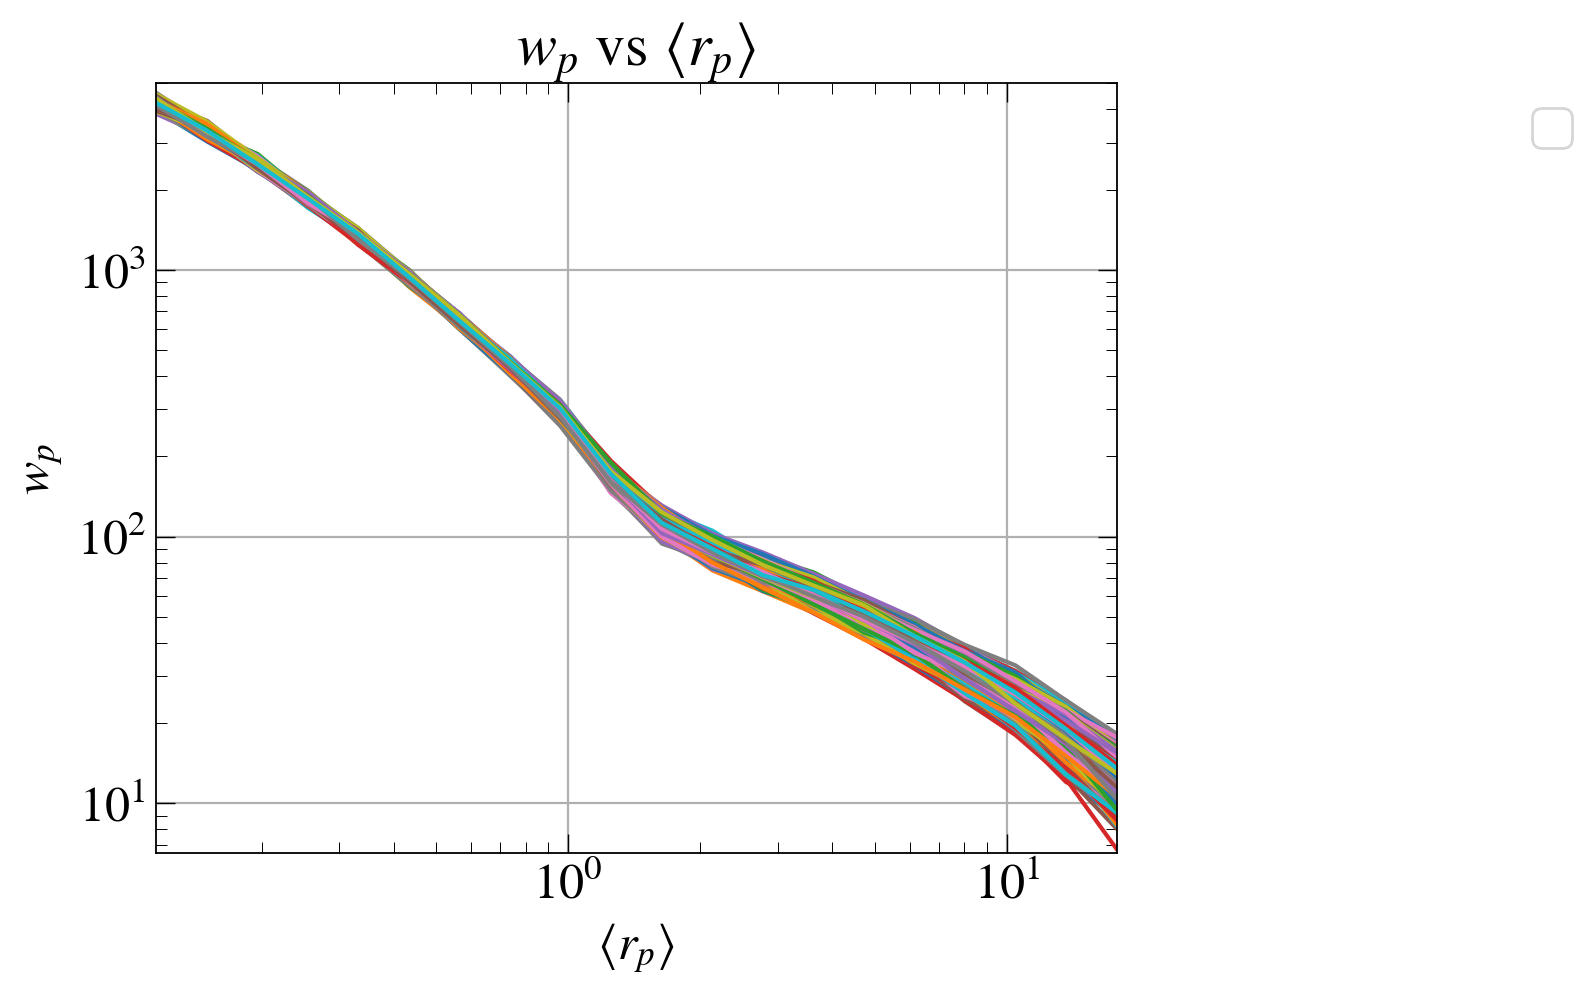

In [11]:

plot_results(rp_, wp_, y_max = 5000, y_min = 6.5)

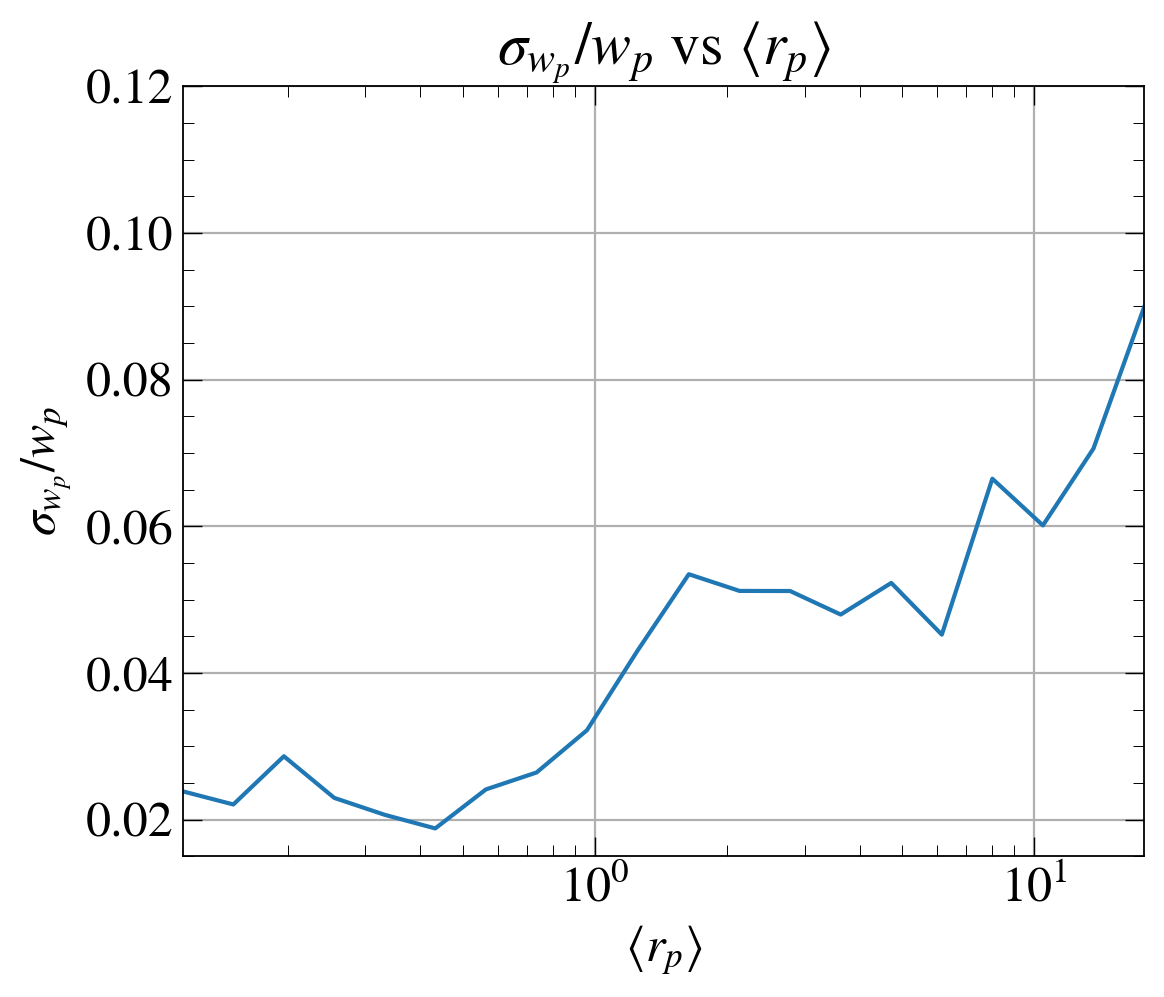

In [13]:
plot_fractional_error(rp_, wp_, y_max = 0.12, y_min = 0.015)

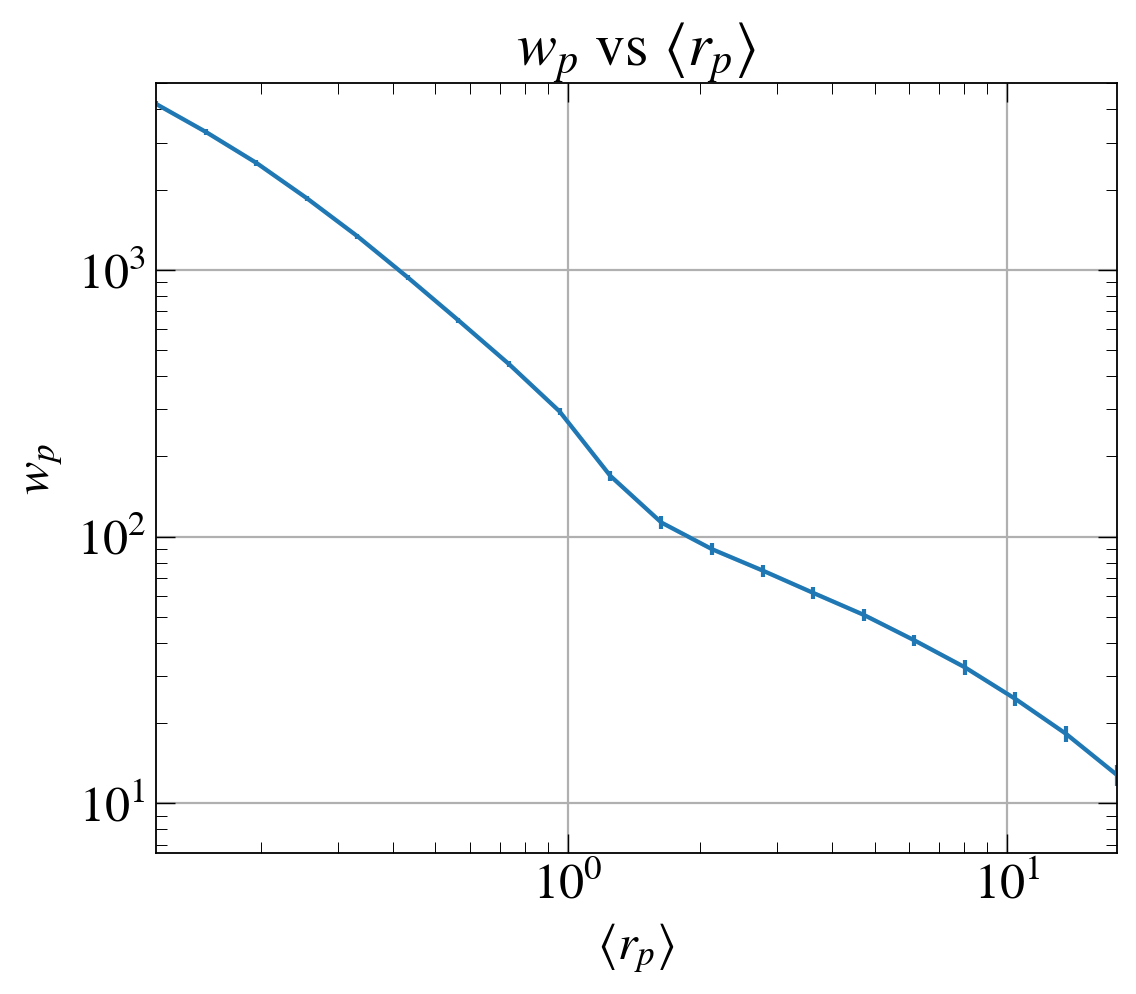

In [14]:
wp_vs_rpavg(rp_, wp_, y_max = 5000, y_min = 6.5)   